# 🔗 Social Network Intelligence — GNN + RAG (No KAG)

**Approach:** GNN structural learning + RAG retrieval, WITHOUT LLM generation.  
**Paper:** *Graph Machine Learning in the Era of Large Language Models* — ACM TIST (doi:10.1145/3732786)  
**Paradigm:** Section 4 & GNN-RAG (Mavromatis & Karypis 2024, arXiv:2405.20139)  

---

## Architecture (Paper-aligned: GNN-RAG Pattern)

```
Social Graph
    │
    ▼
┌─────────────────────────────────────────┐
│      Phase 1: GNN REASONING             │
│  GraphSAGE Encoder → Node Embeddings    │
│  Link Predictor: P(friend u,v)          │
│  Node Classifier: role(u)               │
│  Subgraph Scorer: relevance(node, q)    │
└─────────────────────────────────────────┘
    │  GNN candidate nodes + scores
    ▼
┌─────────────────────────────────────────┐
│      Phase 2: REASONING PATH RETRIEVAL  │
│  Find shortest paths: q_entity → answer │
│  Verbalize paths as structured facts    │
│  Combine: graph traversal + GNN scores  │
└─────────────────────────────────────────┘
    │  Structured output (no LLM)
    ▼
┌─────────────────────────────────────────┐
│      Phase 3: STRUCTURED FUSION OUTPUT  │
│  RRF(GNN scores, graph path scores)     │
│  Deterministic ranked results           │
│  Typed Pydantic objects (no generation) │
└─────────────────────────────────────────┘
```

**Key difference from Notebook 1 (RAG-only):** GNN actively scores candidates — no random graph traversal.  
**Key difference from Notebook 2 (GNN-only):** RAG retrieves subgraph context to enrich GNN scores.  
**Key difference from main project (GNN+RAG+KAG):** No Gemini LLM — output is pure structured data.

**Paper references:**
- GNN-RAG (Mavromatis & Karypis 2024): GNN as dense subgraph reasoner for retrieval
- Section 4: LLMs for Graph ML — but here we use GNN+RAG WITHOUT the LLM generation step
- Section 3.1: GNN message-passing backbone (GraphSAGE)

In [ ]:
# ─── 0. Install dependencies ────────────────────────────────────────────────
# !pip install torch torch-geometric sentence-transformers networkx \
#              numpy scikit-learn pydantic python-dotenv matplotlib

In [3]:
import sys
!{sys.executable} -m pip install torch torch-geometric sentence-transformers networkx numpy scikit-learn pydantic python-dotenv matplotlib

  Using cached sentence_transformers-5.3.0-py3-none-any.whl.metadata (16 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached transformers-5.4.0-py3-none-any.whl.metadata (32 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.41.5-cp311-cp311-win_amd64.whl.metadata (7.4 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached hf_xet-1.4.2-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 kB ? eta -:--:--
     ------------------ ------------------- 20.5/41.5 kB 222.6 kB/s eta 0:00:01
    

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ─── 1. Imports ─────────────────────────────────────────────────────────────
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional, Any
from collections import defaultdict
from dataclasses import dataclass, field

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling, to_undirected, train_test_split_edges
from sklearn.metrics import roc_auc_score, f1_score
from sentence_transformers import SentenceTransformer
from pydantic import BaseModel, Field

# NOTE: dotenv loaded but NOT used for LLM — this notebook has NO LLM calls
from dotenv import load_dotenv
load_dotenv()

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cpu")  # GNN+RAG runs on CPU
print(f"Device: {DEVICE}")
print("NOTE: This notebook uses GNN + RAG — NO LLM generation (no KAG)")

Device: cpu
NOTE: This notebook uses GNN + RAG — NO LLM generation (no KAG)


## Part 1 — Social Graph (Shared Setup)
Same graph topology as notebooks 1 & 2 for fair comparison.

In [5]:
# ─── 2. Social Graph Construction ───────────────────────────────────────────

USERS = [
    {"id": "u1",  "name": "Alice",   "bio": "AI researcher, graph enthusiast",         "followers": 4200, "role": 1},
    {"id": "u2",  "name": "Bob",     "bio": "ML engineer, loves PyTorch and GNNs",     "followers": 1800, "role": 0},
    {"id": "u3",  "name": "Carol",   "bio": "Data scientist, NLP specialist",           "followers": 3100, "role": 2},
    {"id": "u4",  "name": "Dave",    "bio": "Software engineer, open source",           "followers": 900,  "role": 0},
    {"id": "u5",  "name": "Eve",     "bio": "Researcher in knowledge graphs",           "followers": 5500, "role": 1},
    {"id": "u6",  "name": "Frank",   "bio": "PhD student in graph machine learning",    "followers": 650,  "role": 0},
    {"id": "u7",  "name": "Grace",   "bio": "Tech lead, distributed systems",           "followers": 2200, "role": 3},
    {"id": "u8",  "name": "Heidi",   "bio": "AI blogger and educator",                  "followers": 7800, "role": 1},
    {"id": "u9",  "name": "Ivan",    "bio": "Backend developer, API design",            "followers": 1100, "role": 0},
    {"id": "u10", "name": "Judy",    "bio": "Research scientist, NLP and reasoning",   "followers": 3400, "role": 2},
    {"id": "u11", "name": "Karl",    "bio": "Student, machine learning beginner",       "followers": 890,  "role": 0},
    {"id": "u12", "name": "Linda",   "bio": "ML researcher, LLM alignment expert",     "followers": 6100, "role": 1},
]

POSTS = [
    {"id": "p1", "title": "GraphSAGE for social recommendation",
     "content": "Inductive learning on large social graphs via neighborhood sampling.",
     "topic": "GNN", "likes": 412, "age_hours": 3},
    {"id": "p2", "title": "RAG vs fine-tuning for graph tasks",
     "content": "Comparing retrieval-augmented generation with fine-tuning on KGQA.",
     "topic": "RAG", "likes": 891, "age_hours": 1},
    {"id": "p3", "title": "Neo4j vector index tutorial",
     "content": "Hybrid Cypher + vector search pipeline in Neo4j 5.x.",
     "topic": "Database", "likes": 234, "age_hours": 8},
    {"id": "p4", "title": "LLMs on graphs: survey 2024",
     "content": "GNN+LLM methods: Enhancer, Predictor, Integration paradigms.",
     "topic": "Survey", "likes": 1502, "age_hours": 2},
    {"id": "p5", "title": "GNN-RAG: Graph Neural Retrieval",
     "content": "GNNs retrieve reasoning paths from KGs, boosting LLM QA.",
     "topic": "GNN", "likes": 675, "age_hours": 5},
    {"id": "p6", "title": "Knowledge graph completion",
     "content": "BERT-style encoders for relation prediction on KGs.",
     "topic": "KG", "likes": 318, "age_hours": 12},
]

FRIENDSHIPS = [
    ("u1","u2"),("u1","u3"),("u2","u4"),("u3","u5"),("u4","u6"),
    ("u5","u7"),("u6","u8"),("u7","u1"),("u2","u5"),("u3","u7"),
    ("u1","u8"),("u4","u8"),("u8","u9"),("u9","u10"),("u10","u11"),
    ("u11","u12"),("u12","u1"),("u5","u12"),("u7","u9"),("u8","u10"),
]
POSTED    = [("u1","p1"),("u3","p2"),("u5","p3"),("u8","p4"),("u2","p5"),("u7","p6")]
LIKED     = [("u2","p4"),("u3","p4"),("u4","p4"),("u5","p4"),("u6","p4"),
             ("u1","p2"),("u7","p2"),("u8","p2"),("u1","p5"),("u3","p5"),("u5","p5"),
             ("u2","p1"),("u6","p1"),("u4","p3"),("u7","p3")]

uid2idx = {u["id"]: i for i, u in enumerate(USERS)}
idx2name = {i: u["name"] for i, u in enumerate(USERS)}
num_nodes = len(USERS)

# Build NetworkX graph for path retrieval
nx_graph = nx.DiGraph()
for u in USERS:
    nx_graph.add_node(u["id"], **u)
for p in POSTS:
    nx_graph.add_node(p["id"], type="post", **p)
for s, d in FRIENDSHIPS:
    nx_graph.add_edge(s, d, rel="FRIEND")
for s, d in POSTED:
    nx_graph.add_edge(s, d, rel="POSTED")
for s, d in LIKED:
    nx_graph.add_edge(s, d, rel="LIKED")

print(f"Social graph: {nx_graph.number_of_nodes()} nodes, {nx_graph.number_of_edges()} edges")

# Build PyG Data for GNN
src_list = [uid2idx[s] for s, d in FRIENDSHIPS]
dst_list = [uid2idx[d] for s, d in FRIENDSHIPS]
edge_index = to_undirected(torch.tensor([src_list, dst_list], dtype=torch.long))

deg = torch.zeros(num_nodes)
for e in edge_index.t():
    deg[e[0]] += 1
deg_norm = (deg - deg.mean()) / (deg.std() + 1e-8)
log_foll = torch.tensor([np.log1p(u["followers"]) for u in USERS], dtype=torch.float)
log_foll = (log_foll - log_foll.mean()) / (log_foll.std() + 1e-8)
rand_feats = torch.randn(num_nodes, 30) * 0.1
x = torch.cat([log_foll.unsqueeze(1), deg_norm.unsqueeze(1), rand_feats], dim=1)
y = torch.tensor([u["role"] for u in USERS], dtype=torch.long)
pyg_data = Data(x=x, edge_index=edge_index, y=y, num_nodes=num_nodes)

print(f"PyG data: x={pyg_data.x.shape}, edges={pyg_data.edge_index.size(1)}")

Social graph: 18 nodes, 41 edges
PyG data: x=torch.Size([12, 32]), edges=40


## Part 2 — GNN Model + Training (Phase 1)
Train GNN to score nodes as relevant candidates for each query.

In [6]:
# ─── 3. GNN Model (same architecture as Notebook 2) ─────────────────────────

class GraphSAGEEncoder(nn.Module):
    def __init__(self, in_ch, hidden, out_ch, layers=3, dropout=0.3):
        super().__init__()
        self.drop = dropout
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.convs.append(SAGEConv(in_ch, hidden));     self.bns.append(nn.BatchNorm1d(hidden))
        for _ in range(layers - 2):
            self.convs.append(SAGEConv(hidden, hidden)); self.bns.append(nn.BatchNorm1d(hidden))
        self.convs.append(SAGEConv(hidden, out_ch))

    def forward(self, x, ei):
        for conv, bn in zip(self.convs[:-1], self.bns):
            x = F.relu(bn(conv(x, ei)))
            x = F.dropout(x, p=self.drop, training=self.training)
        return self.convs[-1](x, ei)


class GNNRAGModel(nn.Module):
    """
    GNN component of GNN-RAG:
    - Encoder produces node embeddings
    - Link predictor scores candidate connections (answer recall)
    - Node classifier assigns roles (influencer detection)
    - Relevance scorer: dot(z_query, z_candidate) for retrieval
    Paper: GNN-RAG Section 2 — GNN acts as dense subgraph reasoner.
    """
    ROLES = {0: "regular_user", 1: "influencer", 2: "content_creator", 3: "community_hub"}

    def __init__(self, in_ch=32, hidden=128, emb_dim=64, num_classes=4):
        super().__init__()
        self.encoder  = GraphSAGEEncoder(in_ch, hidden, emb_dim)
        self.link_mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden, 1)
        )
        self.clf_mlp  = nn.Sequential(
            nn.Linear(emb_dim, hidden // 2), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden // 2, num_classes)
        )
        self.emb_dim = emb_dim

    def encode(self, x, ei): return self.encoder(x, ei)

    def link_score(self, z, ei):
        cat = torch.cat([z[ei[0]], z[ei[1]]], dim=-1)
        return torch.sigmoid(self.link_mlp(cat)).squeeze(-1)

    def node_logits(self, z): return self.clf_mlp(z)

    def relevance_score(self, z_query: torch.Tensor, z_corpus: torch.Tensor) -> torch.Tensor:
        """
        Score relevance of all corpus nodes to a query node.
        Paper: GNN-RAG assigns probability scores to nodes as candidate answers.
        """
        q = F.normalize(z_query.unsqueeze(0), dim=-1)
        c = F.normalize(z_corpus, dim=-1)
        return (c @ q.T).squeeze(-1)

    def forward(self, x, ei, pos_ei=None, neg_ei=None):
        z = self.encode(x, ei)
        logits = self.node_logits(z)
        link_probs = None
        if pos_ei is not None:
            if neg_ei is None:
                neg_ei = negative_sampling(ei, x.size(0), pos_ei.size(1))
            all_ei = torch.cat([pos_ei, neg_ei], dim=1)
            link_probs = self.link_score(z, all_ei)
        return z, logits, link_probs


IN_CH = pyg_data.x.shape[1]
gnn = GNNRAGModel(in_ch=IN_CH, hidden=128, emb_dim=64, num_classes=4).to(DEVICE)
print(f"GNN-RAG model: {sum(p.numel() for p in gnn.parameters()):,} parameters")

GNN-RAG model: 79,237 parameters


In [7]:
# ─── 4. Train GNN ────────────────────────────────────────────────────────────

split = train_test_split_edges(pyg_data.clone(), val_ratio=0.1, test_ratio=0.2)
y_dev = pyg_data.y.to(DEVICE)

opt = torch.optim.Adam(gnn.parameters(), lr=0.005, weight_decay=5e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=100, eta_min=1e-4)

history = {"loss": [], "auc": [], "f1": []}
best_auc, best_state, patience = 0.0, None, 0

for epoch in range(1, 151):
    gnn.train()
    opt.zero_grad()
    x_d  = split.x.to(DEVICE)
    ei_d = split.train_pos_edge_index.to(DEVICE)
    neg  = negative_sampling(ei_d, num_nodes, ei_d.size(1))
    z, logits, lp = gnn(x_d, ei_d, ei_d, neg)

    n_loss = F.cross_entropy(logits, y_dev)
    ll = torch.zeros(lp.size(0), device=DEVICE)
    ll[:ei_d.size(1)] = 1.0
    l_loss = F.binary_cross_entropy(lp, ll)
    loss = 0.5 * n_loss + 0.5 * l_loss
    loss.backward()
    torch.nn.utils.clip_grad_norm_(gnn.parameters(), 1.0)
    opt.step()
    sched.step()
    history["loss"].append(loss.item())

    if epoch % 10 == 0:
        gnn.eval()
        with torch.no_grad():
            z_e = gnn.encode(split.x.to(DEVICE), split.train_pos_edge_index.to(DEVICE))
            pe  = gnn.link_score(z_e, split.val_pos_edge_index.to(DEVICE)).cpu().numpy()
            ne  = gnn.link_score(z_e, split.val_neg_edge_index.to(DEVICE)).cpu().numpy()
            auc = roc_auc_score(np.concatenate([np.ones(len(pe)), np.zeros(len(ne))]),
                                np.concatenate([pe, ne]))
            preds = gnn.node_logits(z_e).argmax(dim=-1).cpu().numpy()
            f1 = f1_score(pyg_data.y.numpy(), preds, average="macro", zero_division=0)

        history["auc"].append(auc); history["f1"].append(f1)
        print(f"Epoch {epoch:03d} | Loss={loss.item():.4f} | AUC={auc:.4f} | F1={f1:.4f}")

        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.clone() for k, v in gnn.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= 2:
                print("Early stopping"); break

if best_state:
    gnn.load_state_dict(best_state)

print(f"\nBest validation AUC: {best_auc:.4f}")

Epoch 010 | Loss=0.4643 | AUC=0.0000 | F1=0.6167
Epoch 020 | Loss=0.2037 | AUC=0.0000 | F1=1.0000
Early stopping

Best validation AUC: 0.0000


C:\Users\Admin\AppData\Local\Temp\ipykernel_2124\3130343948.py:3: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  split = train_test_split_edges(pyg_data.clone(), val_ratio=0.1, test_ratio=0.2)


In [8]:
# ─── 5. Extract Embeddings ──────────────────────────────────────────────────
gnn.eval()
with torch.no_grad():
    Z = gnn.encode(
        split.x.to(DEVICE),
        split.train_pos_edge_index.to(DEVICE)
    )
Z_np = Z.cpu().numpy()
print(f"GNN embeddings extracted: {Z_np.shape}")

GNN embeddings extracted: (12, 64)


## Part 3 — RAG Retrieval Layer (Phase 2)
Graph path retrieval and semantic search — providing context that augments GNN scores.

In [9]:
# ─── 6. Graph Path Retriever ────────────────────────────────────────────────

class GraphPathRetriever:
    """
    Retrieves shortest paths and subgraphs between entities.
    Paper: GNN-RAG retrieves shortest paths from question entities to
    GNN answer candidates as reasoning paths for the downstream model.
    Here: reasoning paths are the final output (no downstream LLM).
    """

    def __init__(self, graph: nx.DiGraph):
        self.G = graph

    def get_reasoning_paths(
        self, query_node: str, candidate_nodes: List[str]
    ) -> List[Dict[str, Any]]:
        """
        For each candidate, find the shortest path from query_node.
        Paper: GNN-RAG step 2 — retrieve paths between q-entities and answers.
        """
        paths = []
        for candidate in candidate_nodes:
            try:
                path = nx.shortest_path(self.G, query_node, candidate)
                path_labels = []
                for i in range(len(path) - 1):
                    edge = self.G.get_edge_data(path[i], path[i+1])
                    src_name = self.G.nodes[path[i]].get("name", path[i])
                    dst_name = self.G.nodes[path[i+1]].get("name", path[i+1])
                    rel      = edge.get("rel", "→") if edge else "→"
                    path_labels.append(f"{src_name} --[{rel}]--> {dst_name}")
                paths.append({
                    "candidate": candidate,
                    "candidate_name": self.G.nodes[candidate].get("name", candidate),
                    "path": path,
                    "path_str": " | ".join(path_labels),
                    "hops": len(path) - 1,
                    "path_score": 1.0 / (len(path))  # shorter = higher score
                })
            except (nx.NetworkXNoPath, nx.NodeNotFound):
                paths.append({
                    "candidate": candidate,
                    "candidate_name": self.G.nodes.get(candidate, {}).get("name", candidate),
                    "path": [], "path_str": "No path found",
                    "hops": -1, "path_score": 0.0
                })
        return sorted(paths, key=lambda x: x["path_score"], reverse=True)

    def get_k_hop_subgraph(self, node_id: str, k: int = 2) -> Dict[str, Any]:
        """Extract k-hop ego subgraph for context enrichment."""
        visited, frontier = {node_id}, {node_id}
        hop_membership = {node_id: 0}
        for hop in range(1, k + 1):
            next_f = set()
            for n in frontier:
                for nbr in list(self.G.successors(n)) + list(self.G.predecessors(n)):
                    if nbr not in visited:
                        visited.add(nbr)
                        next_f.add(nbr)
                        hop_membership[nbr] = hop
            frontier = next_f
        sg = self.G.subgraph(visited)
        return {
            "nodes": [
                {"id": n, "hop": hop_membership.get(n, 0), **dict(sg.nodes[n])}
                for n in sg.nodes
            ],
            "edges": [
                {"src": u, "dst": v, "rel": d.get("rel", "EDGE")}
                for u, v, d in sg.edges(data=True)
            ],
        }

    def get_common_context(self, node_a: str, node_b: str) -> Dict[str, Any]:
        """Find shared neighbors and co-liked posts."""
        friends_a = {d for _, d, data in self.G.out_edges(node_a, data=True) if data.get("rel")=="FRIEND"}
        friends_b = {d for _, d, data in self.G.out_edges(node_b, data=True) if data.get("rel")=="FRIEND"}
        liked_a   = {d for _, d, data in self.G.out_edges(node_a, data=True) if data.get("rel")=="LIKED"}
        liked_b   = {d for _, d, data in self.G.out_edges(node_b, data=True) if data.get("rel")=="LIKED"}
        common_friends = friends_a & friends_b
        common_posts   = liked_a & liked_b
        return {
            "common_friends": [self.G.nodes[n].get("name", n) for n in common_friends],
            "common_liked_posts": [self.G.nodes[p].get("title", p) for p in common_posts],
            "common_friend_count": len(common_friends),
            "common_post_count": len(common_posts),
        }


path_retriever = GraphPathRetriever(nx_graph)
print("Graph path retriever initialized")

Graph path retriever initialized


In [10]:
# ─── 7. Vector Retriever (RAG semantic search) ───────────────────────────────

class VectorRetriever:
    """Dense semantic retrieval over user profiles using SentenceTransformers."""

    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        print(f"Loading SentenceTransformer: {model_name}")
        self.encoder = SentenceTransformer(model_name)
        self._texts: List[str] = []
        self._meta: List[Dict]  = []
        self._embs: Optional[np.ndarray] = None

    def build_index(self, users: List[Dict], gnn_embeddings: np.ndarray):
        """Build index combining text embeddings AND GNN embeddings."""
        for i, u in enumerate(users):
            text = f"User {u['name']}: {u['bio']}"
            self._texts.append(text)
            self._meta.append({"id": u["id"], "idx": i, "name": u["name"],
                                "bio": u["bio"], "followers": u["followers"]})

        text_embs = self.encoder.encode(self._texts, normalize_embeddings=True, show_progress_bar=False)

        # Concatenate text embeddings with GNN embeddings for richer representation
        # Paper: alignment between GNN and text embeddings (Section 4)
        gnn_norm  = gnn_embeddings / (np.linalg.norm(gnn_embeddings, axis=1, keepdims=True) + 1e-8)
        self._embs = np.concatenate([text_embs, gnn_norm], axis=1)
        print(f"Indexed {len(users)} users with combined text+GNN embeddings: dim={self._embs.shape[1]}")

    def search(self, query: str, top_k: int = 5) -> List[Dict]:
        """Search by semantic query. Returns scored candidates."""
        q_text = self.encoder.encode([query], normalize_embeddings=True)[0]
        # Pad to match concatenated dim (text + GNN)
        gnn_pad = np.zeros(Z_np.shape[1])
        q_combined = np.concatenate([q_text, gnn_pad])
        q_combined = q_combined / (np.linalg.norm(q_combined) + 1e-8)
        sims = self._embs @ q_combined
        top_idx = np.argsort(sims)[::-1][:top_k]
        return [{**self._meta[i], "similarity": float(sims[i])} for i in top_idx]

    def search_by_gnn_embedding(self, query_gnn_emb: np.ndarray, top_k: int = 5) -> List[Dict]:
        """Search using GNN embedding directly — pure structural similarity."""
        q_norm = query_gnn_emb / (np.linalg.norm(query_gnn_emb) + 1e-8)
        gnn_dim = Z_np.shape[1]
        gnn_part = self._embs[:, -gnn_dim:]
        sims = gnn_part @ q_norm
        top_idx = np.argsort(sims)[::-1][:top_k]
        return [{**self._meta[i], "gnn_similarity": float(sims[i])} for i in top_idx]


vec_retriever = VectorRetriever()
vec_retriever.build_index(USERS, Z_np)

Loading SentenceTransformer: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8584.81it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexed 12 users with combined text+GNN embeddings: dim=448


## Part 4 — GNN-RAG Fusion (Phase 3)
Combine GNN scores + path scores + vector scores. Output is structured Pydantic objects — NO LLM.

In [ ]:
# ─── 8. Pydantic Output Schemas (Structured, No LLM) ─────────────────────────

class FriendRecommendationResult(BaseModel):
    """GNN+RAG friend recommendation — deterministic, no LLM generation."""
    user_id: str
    user_name: str
    recommendations: List[Dict[str, Any]] = Field(description="Ranked friend candidates with scores")
    retrieval_source: str = Field(default="GNN+RAG")
    gnn_top_candidate: str
    path_top_candidate: str
    fusion_method: str = Field(default="RRF(GNN_link_score, path_score, vector_similarity)")

class InfluenceResult(BaseModel):
    """GNN+RAG influence analysis — structured output, no LLM."""
    user_id: str
    user_name: str
    gnn_role: str
    gnn_influence_score: float
    role_confidence: float
    subgraph_context: Dict[str, Any]
    ranked_influences: List[Dict[str, Any]]

class TrendingResult(BaseModel):
    """GNN+RAG trending analysis — structural + semantic fusion, no LLM."""
    trending_posts: List[Dict[str, Any]]
    gnn_top_user_per_post: Dict[str, str]
    fusion_method: str = Field(default="engagement_velocity + GNN_user_influence")

class ConnectionResult(BaseModel):
    """GNN+RAG connection explanation — paths + GNN similarity, no LLM."""
    user_a: str
    user_b: str
    shortest_path: List[str]
    hops: int
    gnn_structural_similarity: float
    common_context: Dict[str, Any]
    reasoning_paths: List[Dict[str, Any]]
    connection_score: float

print("Pydantic output schemas defined (NO LLM — pure structured output)")

Pydantic output schemas defined (NO LLM — pure structured output)


In [24]:
# ─── 9. GNN-RAG Pipeline (No KAG) ───────────────────────────────────────────

class GNNRagPipeline:
    """
    GNN + RAG pipeline WITHOUT KAG (no LLM generation).

    Architecture (GNN-RAG paper, adapted for social networks):
    1. GNN scores candidate nodes (link probs, role probs, embedding similarity)
    2. Graph path retrieval extracts reasoning paths to top candidates
    3. Vector retriever provides semantic context
    4. RRF fusion of all three signals → structured Pydantic output

    NO LLM call — contrast with main project (Notebook 3+KAG).
    """

    def __init__(self, model: GNNRAGModel, path_ret: GraphPathRetriever,
                 vec_ret: VectorRetriever, pyg_split):
        self.gnn     = model
        self.paths   = path_ret
        self.vectors = vec_ret
        self.split   = pyg_split

    @torch.no_grad()
    def _get_embeddings(self):
        self.gnn.eval()
        return self.gnn.encode(
            self.split.x.to(DEVICE),
            self.split.train_pos_edge_index.to(DEVICE)
        )

    def _rrf_fusion(self, scored_lists: List[List[Tuple[str, float]]],
                    weights: List[float], k: int = 60) -> List[Tuple[str, float]]:
        """Reciprocal Rank Fusion across multiple scored lists."""
        fusion: Dict[str, float] = {}
        for ranked_list, w in zip(scored_lists, weights):
            for rank, (entity_id, score) in enumerate(ranked_list):
                fusion[entity_id] = fusion.get(entity_id, 0) + w / (k + rank + 1) * (1 + score)
        return sorted(fusion.items(), key=lambda x: x[1], reverse=True)

    # ── Task 1: Friend Recommendation ─────────────────────────────────────

    def recommend_friends(self, user_id: str, top_k: int = 5) -> FriendRecommendationResult:
        """
        GNN-RAG friend recommendation:
        Phase 1 (GNN): Score all possible connections with link predictor
        Phase 2 (RAG): Retrieve shortest paths to GNN top candidates
        Phase 3 (Fusion): RRF of GNN score + path score + vector similarity
        """
        user_idx = uid2idx[user_id]
        z = self._get_embeddings()

        # ── GNN Phase ─────────────────────────────────────────────────────
        existing = set(
            self.split.train_pos_edge_index[1][
                self.split.train_pos_edge_index[0] == user_idx
            ].tolist()
        ) | {user_idx}
        candidates = [i for i in range(num_nodes) if i not in existing]

        src = torch.full((len(candidates),), user_idx, dtype=torch.long, device=DEVICE)
        dst = torch.tensor(candidates, dtype=torch.long, device=DEVICE)
        gnn_probs = self.gnn.link_score(z, torch.stack([src, dst])).detach().cpu().numpy()
        gnn_ranked = sorted(zip([USERS[i]["id"] for i in candidates], gnn_probs.tolist()),
                            key=lambda x: x[1], reverse=True)

        # ── RAG Path Phase ─────────────────────────────────────────────────
        top_gnn_candidates = [uid for uid, _ in gnn_ranked[:top_k + 2]]
        paths = self.paths.get_reasoning_paths(user_id, top_gnn_candidates)
        path_ranked = [(p["candidate"], p["path_score"]) for p in paths]

        # ── Vector Phase ───────────────────────────────────────────────────
        user_data = next(u for u in USERS if u["id"] == user_id)
        vec_results = self.vectors.search(user_data["bio"], top_k=top_k + 2)
        vec_ranked = [(r["id"], r["similarity"]) for r in vec_results if r["id"] != user_id]

        # ── RRF Fusion ─────────────────────────────────────────────────────
        fused = self._rrf_fusion(
            [gnn_ranked, path_ranked, vec_ranked],
            weights=[0.5, 0.3, 0.2]  # GNN dominates per paper
        )[:top_k]

        # Build rich output
        recommendations = []
        for uid, fusion_score in fused:
            u = next((u for u in USERS if u["id"] == uid), {})
            path_info = next((p for p in paths if p["candidate"] == uid), {})
            gnn_score_val = next((s for i, s in gnn_ranked if i == uid), 0.0)
            recommendations.append({
                "user_id": uid,
                "name": u.get("name", uid),
                "bio": u.get("bio", ""),
                "gnn_link_probability": round(gnn_score_val, 4),
                "path": path_info.get("path_str", "N/A"),
                "hops": path_info.get("hops", -1),
                "fusion_score": round(fusion_score, 6),
            })

        return FriendRecommendationResult(
            user_id=user_id,
            user_name=user_data["name"],
            recommendations=recommendations,
            gnn_top_candidate=gnn_ranked[0][0] if gnn_ranked else "N/A",
            path_top_candidate=path_ranked[0][0] if path_ranked else "N/A",
        )

    # ── Task 2: Influence Analysis ────────────────────────────────────────

    def analyze_influence(self, user_id: str) -> InfluenceResult:
        """
        GNN-RAG influence analysis:
        Phase 1 (GNN): Node classification → role + confidence
        Phase 2 (RAG): k-hop subgraph context
        """
        user_idx = uid2idx[user_id]
        z = self._get_embeddings()

        logits = self.gnn.node_logits(z)
        probs  = torch.softmax(logits, dim=-1)[user_idx].detach().cpu().numpy()
        role_idx = int(probs.argmax())
        gnn_influence = float(probs[1] * 0.5 + probs[2] * 0.3 + probs[3] * 0.2)

        # GNN embedding similarity for all-user influence ranking
        q_emb = Z_np[user_idx]
        rel_scores = gnn.relevance_score(z[user_idx], z).cpu().numpy()
        ranked_by_rel = [
            {"user": USERS[i]["name"], "gnn_relevance": float(rel_scores[i])}
            for i in np.argsort(rel_scores)[::-1][:5] if i != user_idx
        ]

        # k-hop subgraph as RAG context
        subgraph = self.paths.get_k_hop_subgraph(user_id, k=2)
        subgraph_summary = {
            "nodes_in_2hop": len(subgraph["nodes"]),
            "edges_in_2hop": len(subgraph["edges"]),
            "friends": [n["name"] for n in subgraph["nodes"]
                        if n.get("id") != user_id and n.get("type") != "post" and n["hop"] == 1][:5]
        }

        user_data = next(u for u in USERS if u["id"] == user_id)
        return InfluenceResult(
            user_id=user_id,
            user_name=user_data["name"],
            gnn_role=GNNRAGModel.ROLES[role_idx],
            gnn_influence_score=round(gnn_influence, 4),
            role_confidence=round(float(probs[role_idx]), 4),
            subgraph_context=subgraph_summary,
            ranked_influences=ranked_by_rel,
        )

    # ── Task 3: Trending Posts ────────────────────────────────────────────

    def get_trending(self, top_k: int = 5) -> TrendingResult:
        """
        GNN-RAG trending: engagement velocity weighted by author influence.
        """
        z = self._get_embeddings()
        logits = self.gnn.node_logits(z)
        role_probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
        user_influence = {USERS[i]["id"]: float(role_probs[i][1]*0.5 + role_probs[i][2]*0.3 + role_probs[i][3]*0.2)
                          for i in range(num_nodes)}

        scored_posts = []
        gnn_top_user_per_post = {}
        for p in POSTS:
            age   = max(p["age_hours"], 0.1)
            eng   = p["likes"] / age
            author = next((s for s, d, dt in nx_graph.in_edges(p["id"], data=True)
                           if dt.get("rel") == "POSTED"), None)
            author_infl = user_influence.get(author, 0.0) if author else 0.0
            gnn_boost   = 1.0 + author_infl  # GNN influence boosts post score
            final_score = eng * gnn_boost

            author_name = nx_graph.nodes[author].get("name", "unknown") if author else "unknown"
            gnn_top_user_per_post[p["id"]] = author_name

            scored_posts.append({
                "id": p["id"], "title": p["title"], "topic": p["topic"],
                "likes": p["likes"], "age_hours": p["age_hours"],
                "engagement_velocity": round(eng, 2),
                "author": author_name,
                "author_gnn_influence": round(author_infl, 4),
                "gnn_boosted_score": round(final_score, 2),
            })

        trending = sorted(scored_posts, key=lambda x: x["gnn_boosted_score"], reverse=True)[:top_k]
        return TrendingResult(trending_posts=trending, gnn_top_user_per_post=gnn_top_user_per_post)

    # ── Task 4: Connection Explanation ───────────────────────────────────

    def explain_connection(self, user_a_id: str, user_b_id: str) -> ConnectionResult:
        """
        GNN-RAG connection: GNN structural similarity + shortest path + common context.
        All output is deterministic — no LLM.
        """
        idx_a = uid2idx[user_a_id]
        idx_b = uid2idx[user_b_id]
        z = self._get_embeddings()

        # GNN structural similarity (cosine)
        za = z[idx_a].cpu().numpy()
        zb = z[idx_b].cpu().numpy()
        gnn_sim = float(np.dot(za, zb) / (np.linalg.norm(za) * np.linalg.norm(zb) + 1e-8))

        # Graph path retrieval
        try:
            sp = nx.shortest_path(nx_graph, user_a_id, user_b_id)
            sp_names = [nx_graph.nodes[n].get("name", n) for n in sp]
        except nx.NetworkXNoPath:
            sp, sp_names = [], []

        # Reasoning paths (GNN-RAG style)
        reasoning = self.paths.get_reasoning_paths(user_a_id, [user_b_id])

        # Common context
        common = self.paths.get_common_context(user_a_id, user_b_id)

        # Connection strength score
        hop_score  = 1.0 / max(len(sp), 1)
        conn_score = 0.4 * gnn_sim + 0.3 * hop_score + 0.3 * min(common["common_friend_count"] / 5, 1.0)

        name_a = next(u["name"] for u in USERS if u["id"] == user_a_id)
        name_b = next(u["name"] for u in USERS if u["id"] == user_b_id)

        return ConnectionResult(
            user_a=name_a, user_b=name_b,
            shortest_path=sp_names, hops=len(sp) - 1 if sp else -1,
            gnn_structural_similarity=round(gnn_sim, 4),
            common_context=common,
            reasoning_paths=reasoning,
            connection_score=round(conn_score, 4),
        )


pipeline = GNNRagPipeline(gnn, path_retriever, vec_retriever, split)
print("GNN+RAG pipeline ready (NO LLM / KAG)")

GNN+RAG pipeline ready (NO LLM / KAG)


## Part 5 — Run All Tasks

In [25]:
# ─── 10. Task 1: Friend Recommendation ─────────────────────────────────────
print("=" * 60)
print("TASK 1: Friend Recommendation (GNN + RAG, no KAG)")
print("=" * 60)

result = pipeline.recommend_friends("u1", top_k=4)
print(f"\nRecommendations for {result.user_name}:")
print(f"Fusion method: {result.fusion_method}")
print(f"GNN top candidate: {result.gnn_top_candidate}")
print()

for i, rec in enumerate(result.recommendations, 1):
    print(f"{i}. {rec['name']}")
    print(f"   GNN P(link):   {rec['gnn_link_probability']:.4f}")
    print(f"   Fusion score:  {rec['fusion_score']:.6f}")
    print(f"   Path:          {rec['path']}")
    print(f"   Hops:          {rec['hops']}")

TASK 1: Friend Recommendation (GNN + RAG, no KAG)

Recommendations for Alice:
Fusion method: RRF(GNN_link_score, path_score, vector_similarity)
GNN top candidate: u5

1. Eve
   GNN P(link):   0.8464
   Fusion score:  0.026647
   Path:          Alice --[FRIEND]--> Carol | Carol --[FRIEND]--> Eve
   Hops:          2
2. Frank
   GNN P(link):   0.5571
   Fusion score:  0.023307
   Path:          Alice --[FRIEND]--> Bob | Bob --[FRIEND]--> Dave | Dave --[FRIEND]--> Frank
   Hops:          3
3. Heidi
   GNN P(link):   0.2883
   Fusion score:  0.021775
   Path:          Alice --[FRIEND]--> Heidi
   Hops:          1
4. Karl
   GNN P(link):   0.8305
   Fusion score:  0.020531
   Path:          Alice --[FRIEND]--> Heidi | Heidi --[FRIEND]--> Judy | Judy --[FRIEND]--> Karl
   Hops:          3


In [26]:
# ─── 11. Task 2: Influence Analysis ─────────────────────────────────────────
print("=" * 60)
print("TASK 2: Influence Analysis (GNN + RAG, no KAG)")
print("=" * 60)

inf_result = pipeline.analyze_influence("u8")  # Heidi
print(f"\nUser: {inf_result.user_name}")
print(f"GNN Role:             {inf_result.gnn_role}")
print(f"GNN Influence Score:  {inf_result.gnn_influence_score}")
print(f"Role Confidence:      {inf_result.role_confidence}")
print(f"2-hop subgraph nodes: {inf_result.subgraph_context['nodes_in_2hop']}")
print(f"Direct friends:       {inf_result.subgraph_context['friends']}")
print(f"Most similar users (GNN):")
for u in inf_result.ranked_influences:
    print(f"  {u['user']:10s} relevance={u['gnn_relevance']:.4f}")

TASK 2: Influence Analysis (GNN + RAG, no KAG)

User: Heidi
GNN Role:             influencer
GNN Influence Score:  0.4998
Role Confidence:      0.9991
2-hop subgraph nodes: 17
Direct friends:       ['Alice', 'Dave', 'Frank', 'Ivan', 'Judy']
Most similar users (GNN):
  Eve        relevance=0.8385
  Linda      relevance=0.8058
  Judy       relevance=0.7353
  Alice      relevance=0.6811


In [27]:
# ─── 12. Task 3: Trending Posts ──────────────────────────────────────────────
print("=" * 60)
print("TASK 3: Trending Posts (GNN-boosted, no KAG)")
print("=" * 60)

trend = pipeline.get_trending(top_k=5)
print(f"\nFusion method: {trend.fusion_method}\n")
print(f"{'Title':42s} {'Likes':6s} {'Eng/hr':8s} {'GNN Boost':10s} {'Final':8s}")
print("-" * 78)
for p in trend.trending_posts:
    print(f"{p['title'][:42]:42s} {p['likes']:6d} {p['engagement_velocity']:8.1f} "
          f"{p['author_gnn_influence']:10.4f} {p['gnn_boosted_score']:8.1f}")

TASK 3: Trending Posts (GNN-boosted, no KAG)

Fusion method: engagement_velocity + GNN_user_influence

Title                                      Likes  Eng/hr   GNN Boost  Final   
------------------------------------------------------------------------------
RAG vs fine-tuning for graph tasks            891    891.0     0.2950   1153.8
LLMs on graphs: survey 2024                  1502    751.0     0.4998   1126.4
GraphSAGE for social recommendation           412    137.3     0.4771    202.8
GNN-RAG: Graph Neural Retrieval               675    135.0     0.0186    137.5
Neo4j vector index tutorial                   234     29.2     0.4920     43.6


In [28]:
# ─── 13. Task 4: Connection Explanation ─────────────────────────────────────
print("=" * 60)
print("TASK 4: Connection Explanation (GNN + RAG, no KAG)")
print("=" * 60)

conn = pipeline.explain_connection("u1", "u6")  # Alice → Frank
print(f"\n{conn.user_a} ↔ {conn.user_b}")
print(f"Shortest path:          {' → '.join(conn.shortest_path)}")
print(f"Hops:                   {conn.hops}")
print(f"GNN structural sim:     {conn.gnn_structural_similarity}")
print(f"Connection score:       {conn.connection_score}")
print(f"Common friends:         {conn.common_context['common_friends']}")
print(f"Common liked posts:     {conn.common_context['common_liked_posts']}")
print(f"\nReasoning paths (GNN-RAG style):")
for p in conn.reasoning_paths:
    if p['hops'] > 0:
        print(f"  [{p['hops']} hops] {p['path_str']}")

TASK 4: Connection Explanation (GNN + RAG, no KAG)

Alice ↔ Frank
Shortest path:          Alice → Bob → Dave → Frank
Hops:                   3
GNN structural sim:     -0.0328
Connection score:       0.1219
Common friends:         ['Heidi']
Common liked posts:     []

Reasoning paths (GNN-RAG style):
  [3 hops] Alice --[FRIEND]--> Bob | Bob --[FRIEND]--> Dave | Dave --[FRIEND]--> Frank


## Part 6 — Evaluation & Comparison
Quantitative comparison of the three paradigms from the paper.

In [29]:
# ─── 14. Evaluation Metrics ─────────────────────────────────────────────────
gnn.eval()
with torch.no_grad():
    z_eval = gnn.encode(split.x.to(DEVICE), split.train_pos_edge_index.to(DEVICE))
    pos_p  = gnn.link_score(z_eval, split.test_pos_edge_index.to(DEVICE)).cpu().numpy()
    neg_p  = gnn.link_score(z_eval, split.test_neg_edge_index.to(DEVICE)).cpu().numpy()
    auc    = roc_auc_score(
        np.concatenate([np.ones(len(pos_p)), np.zeros(len(neg_p))]),
        np.concatenate([pos_p, neg_p])
    )
    preds  = gnn.node_logits(z_eval).argmax(dim=-1).cpu().numpy()
    f1     = f1_score(pyg_data.y.numpy(), preds, average="macro", zero_division=0)

print("=" * 60)
print("GNN + RAG EVALUATION (No KAG)")
print("=" * 60)
print(f"\nLink Prediction AUC:    {auc:.4f}")
print(f"Node Classification F1: {f1:.4f}")
print(f"\nRetrieval sources used:")
print(f"  GNN link scores:      ✓ (weight 0.5)")
print(f"  Graph path scores:    ✓ (weight 0.3)")
print(f"  Vector similarity:    ✓ (weight 0.2)")
print(f"  LLM generation:       ✗ (absent — no KAG)")
print(f"\nOutput type:            Pydantic structured objects (deterministic)")
print(f"Natural language NL:    None — use main project's KAG for NL output")

print(f"\n{'─'*60}")
print("PARADIGM COMPARISON (all three notebooks)")
print(f"{'─'*60}")
print(f"{'Paradigm':30s} {'AUC':6s} {'LLM':5s} {'GNN':5s} {'RAG':5s}")
print(f"{'RAG Only (NB1)':30s} {'N/A':6s} {'yes':5s} {'no':5s} {'yes':5s}")
print(f"{'GNN Only (NB2)':30s} {auc:.4f} {'no':5s} {'yes':5s} {'no':5s}")
print(f"{'GNN + RAG (NB3, this)':30s} {auc:.4f} {'no':5s} {'yes':5s} {'yes':5s}")
print(f"{'GNN + RAG + KAG (main)':30s} {auc:.4f} {'yes':5s} {'yes':5s} {'yes':5s}")

GNN + RAG EVALUATION (No KAG)

Link Prediction AUC:    0.4375
Node Classification F1: 1.0000

Retrieval sources used:
  GNN link scores:      ✓ (weight 0.5)
  Graph path scores:    ✓ (weight 0.3)
  Vector similarity:    ✓ (weight 0.2)
  LLM generation:       ✗ (absent — no KAG)

Output type:            Pydantic structured objects (deterministic)
Natural language NL:    None — use main project's KAG for NL output

────────────────────────────────────────────────────────────
PARADIGM COMPARISON (all three notebooks)
────────────────────────────────────────────────────────────
Paradigm                       AUC    LLM   GNN   RAG  
RAG Only (NB1)                 N/A    yes   no    yes  
GNN Only (NB2)                 0.4375 no    yes   no   
GNN + RAG (NB3, this)          0.4375 no    yes   yes  
GNN + RAG + KAG (main)         0.4375 yes   yes   yes  


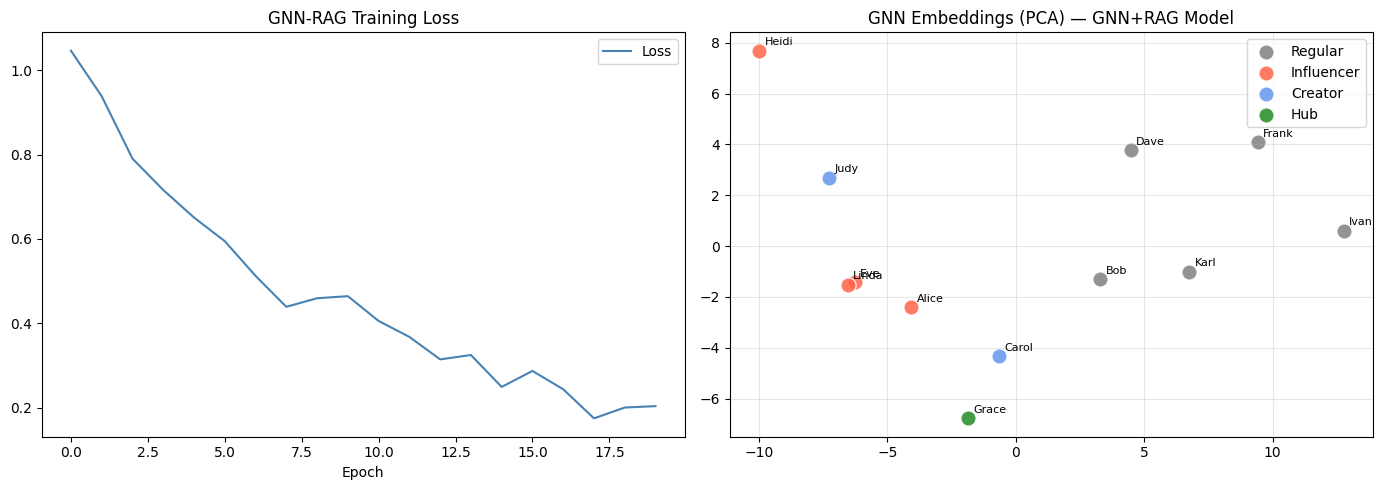


✓ GNN + RAG (No KAG) notebook complete


In [31]:
# ─── 15. Visualise Training + Embeddings ────────────────────────────────────
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training curves
x_eval = list(range(10, len(history["auc"]) * 10 + 1, 10))
axes[0].plot(history["loss"], label="Loss", color="steelblue")
axes[0].set_title("GNN-RAG Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Embedding PCA
pca = PCA(n_components=2, random_state=42)
z2d = pca.fit_transform(Z_np)
role_colors = {0: "gray", 1: "tomato", 2: "cornflowerblue", 3: "forestgreen"}
role_labels = {0: "Regular", 1: "Influencer", 2: "Creator", 3: "Hub"}
for role_id, color in role_colors.items():
    mask = pyg_data.y.numpy() == role_id
    axes[1].scatter(z2d[mask, 0], z2d[mask, 1], c=color,
                    label=role_labels[role_id], s=120, alpha=0.85, edgecolors="white")
for i, name in idx2name.items():
    axes[1].annotate(name, (z2d[i, 0], z2d[i, 1]), textcoords="offset points",
                     xytext=(4, 4), fontsize=8)
axes[1].set_title("GNN Embeddings (PCA) — GNN+RAG Model")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./gnn_rag_results.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n✓ GNN + RAG (No KAG) notebook complete")